# Lazypredict

In [24]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd

In [25]:
df = pd.read_excel("../Data Final/Final_PM14.xlsx")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Start_Time               906 non-null    datetime64[us]
 1   End_Time                 906 non-null    datetime64[us]
 2   Data_Count               906 non-null    int64         
 3   Mean_Creping             906 non-null    float64       
 4   Mean_Yankee Speed        906 non-null    float64       
 5   Mean_Pope Reel Speed     906 non-null    float64       
 6   Mean_Yankee Pressure     906 non-null    float64       
 7   Mean_Stock Flow          906 non-null    float64       
 8   Mean_Stock Consistency   906 non-null    float64       
 9   Mean_Flow Coating        906 non-null    float64       
 10  Mean_Flow Release        906 non-null    float64       
 11  Mean_Jet Wire Ratio      906 non-null    float64       
 12  Mean_Load KWH Refiner    906 non-null    float6

In [26]:
# Data Preparation

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

# Cleaning - GSM
df['GSM'] = df['GSM'].astype(str)
df = df[df['GSM'].str.len() <= 4].copy()
df['GSM'] = df['GSM'].str.replace(',', '.')
df['GSM'] = df['GSM'].astype(float)

# Create Pseudo_Mass Feature
df['pseudo_mass'] = (df['Mean_Stock Flow'] * df['Mean_Stock Consistency'])/ df['Mean_Yankee Speed']

# Create Coating-Release Ratio Feature
df['coating_release_ratio'] = df['Mean_Flow Coating'] / df['Mean_Flow Release']

# X Variables
features = [
    'Mean_Yankee Speed',
    'Mean_Pope Reel Speed',
    'Mean_Yankee Pressure',
    'Mean_Creping',
    '% NBKP',
    'Mean_Load KWH Refiner',
    'Mean_Jet Wire Ratio',
    'GSM',
    'coating_release_ratio',
    'pseudo_mass',
    'Mean_Coating/(Area.Min)'
]
X = df[features]

# Y Variables
y = df['MDT']

In [27]:
X.tail()

,Mean_Yankee Speed,Mean_Pope Reel Speed,Mean_Yankee Pressure,Mean_Creping,% NBKP,Mean_Load KWH Refiner,Mean_Jet Wire Ratio,GSM,coating_release_ratio,pseudo_mass,Mean_Coating/(Area.Min)
880,1199.069574,863.317803,7.398770,28.001003,18.893424,223.481410,0.930000,12.5,0.786670,3.030610,0.000488
881,1199.961111,868.176200,7.397889,27.649638,18.893424,229.104467,0.930000,12.5,0.786669,3.065399,0.000488
882,1199.942323,873.550935,7.397871,27.200588,18.893424,232.056306,0.932419,12.5,0.735810,3.065657,0.000480
883,1203.908238,876.220485,7.398178,27.217770,18.893424,240.124594,0.940000,12.5,0.679804,3.061127,0.000467
884,1196.773150,860.269381,7.398265,28.121759,18.893424,233.135451,0.940000,12.5,0.695135,3.017183,0.000467


In [28]:
y.head()

7     279
8     332
9     228
10    268
11    317
Name: MDT, dtype: int64

In [29]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

In [31]:
# Hitung MAPE untuk tiap model
mape_scores = {}

for model_name, y_pred in predictions.items():
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mape_scores[model_name] = mape

# Tambahkan ke tabel hasil
models["MAPE"] = pd.Series(mape_scores)

# Urutkan (semakin kecil semakin baik)
models = models.sort_values(by="MAPE")

In [32]:
print(models)

                               Adjusted R-Squared    R-Squared         RMSE  \
Model                                                                         
ExtraTreesRegressor                      0.705011     0.745071    57.565639   
GradientBoostingRegressor                0.683645     0.726607    59.613912   
KNeighborsRegressor                      0.665283     0.710738    61.319622   
RandomForestRegressor                    0.665086     0.710568    61.337655   
BaggingRegressor                         0.642940     0.691430    63.333120   
HuberRegressor                           0.641551     0.690229    63.456260   
PassiveAggressiveRegressor               0.636234     0.685634    63.925154   
Lars                                     0.631000     0.681111    64.383379   
TransformedTargetRegressor               0.631000     0.681111    64.383379   
LinearRegression                         0.631000     0.681111    64.383379   
Ridge                                    0.627701   

# Regressor

In [33]:
# Import Libraries
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load Data -> sudah sebelumnya
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Inisialisasi Model Random Forest
model = ExtraTreesRegressor(
    n_estimators=300,     # jumlah pohon
    max_depth=15,       # kedalaman pohon (None = bebas)
    min_samples_split=4,
    min_samples_leaf=1,
    max_features=0.7,
    random_state=42,
    n_jobs=-1,
    bootstrap=True
)

# Training Model
model.fit(X_train, y_train)
# Prediksi
y_pred = model.predict(X_test)

# Evaluasi Model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# MAPE Manual (aman)
epsilon = 1e-8
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon)))

print("R2       :", r2)
print("RMSE     :", rmse)
print("MAE      :", mae)
print("MAPE     :", mape)

R2       : 0.7426225079120192
RMSE     : 57.841468796208126
MAE      : 46.252780685003415
MAPE     : 0.10187175788613728


### Pickle Files

In [34]:
import joblib

In [35]:
#joblib.dump(model, 'model.pkl')

In [36]:
features_pkl = X.columns.tolist()
#joblib.dump(features_pkl, 'features.pkl')

### Features Importance

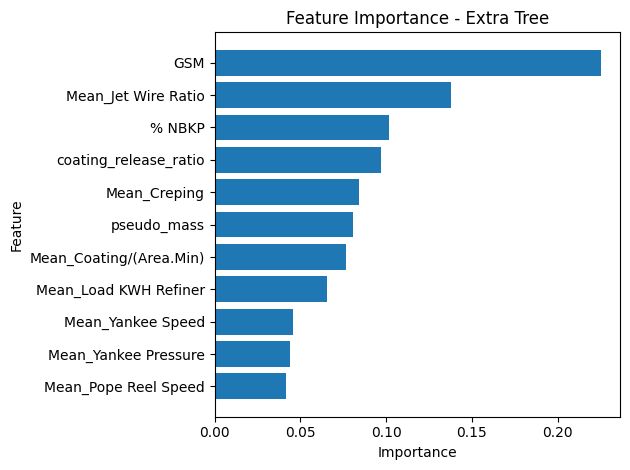

In [37]:
# Feature Importance
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": features, 
    "Importance": model.feature_importances_
})

# Urutkan dari terbesar
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)


# Plot
import matplotlib.pyplot as plt
plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Extra Tree")

plt.tight_layout()
plt.show()

### SHAP Analysis

In [38]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [39]:
print(X_train.shape)
print(X_test.shape)

(328, 11)
(82, 11)


In [40]:
print(list(X_train.columns))
print(list(X_test.columns))

['Mean_Yankee Speed', 'Mean_Pope Reel Speed', 'Mean_Yankee Pressure', 'Mean_Creping', '% NBKP', 'Mean_Load KWH Refiner', 'Mean_Jet Wire Ratio', 'GSM', 'coating_release_ratio', 'pseudo_mass', 'Mean_Coating/(Area.Min)']
['Mean_Yankee Speed', 'Mean_Pope Reel Speed', 'Mean_Yankee Pressure', 'Mean_Creping', '% NBKP', 'Mean_Load KWH Refiner', 'Mean_Jet Wire Ratio', 'GSM', 'coating_release_ratio', 'pseudo_mass', 'Mean_Coating/(Area.Min)']


In [41]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Mean_Yankee Speed          0
Mean_Pope Reel Speed       0
Mean_Yankee Pressure       0
Mean_Creping               0
% NBKP                     0
Mean_Load KWH Refiner      0
Mean_Jet Wire Ratio        0
GSM                        0
coating_release_ratio      0
pseudo_mass                0
Mean_Coating/(Area.Min)    0
dtype: int64
Mean_Yankee Speed          0
Mean_Pope Reel Speed       0
Mean_Yankee Pressure       0
Mean_Creping               0
% NBKP                     0
Mean_Load KWH Refiner      0
Mean_Jet Wire Ratio        0
GSM                        0
coating_release_ratio      0
pseudo_mass                0
Mean_Coating/(Area.Min)    0
dtype: int64


In [42]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

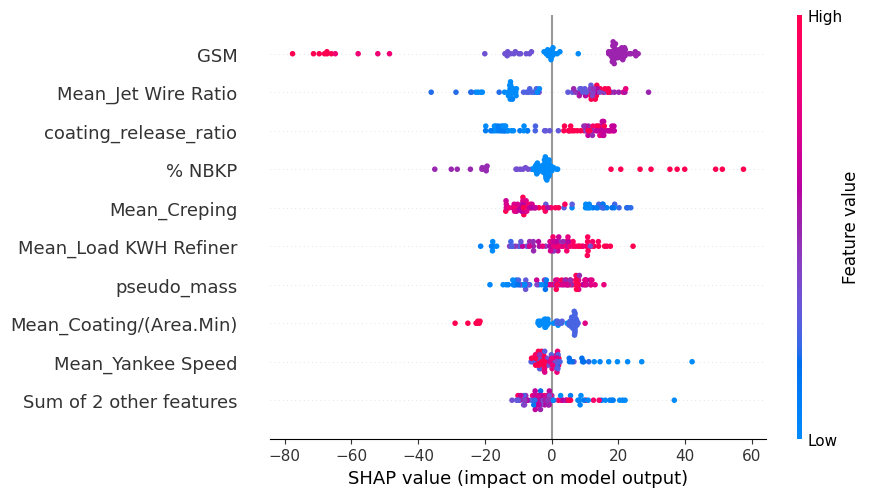

In [43]:
shap.plots.beeswarm(shap_values, max_display=10)

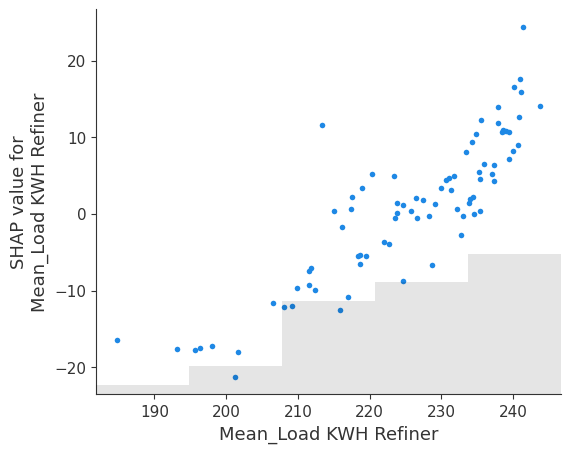

In [44]:
shap.plots.scatter(shap_values[:, "Mean_Load KWH Refiner"])

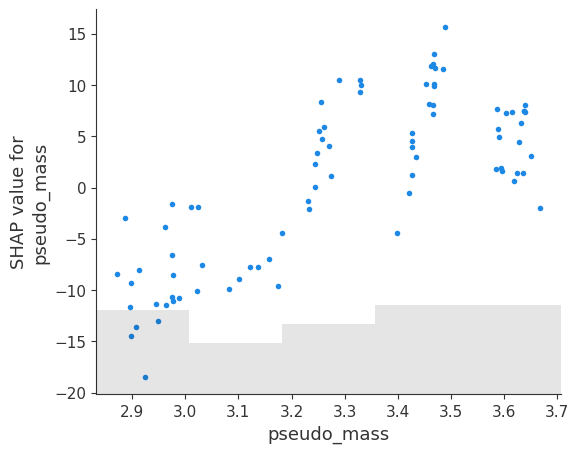

In [45]:
shap.plots.scatter(shap_values[:, "pseudo_mass"])

In [46]:
shap_values = explainer.shap_values(np.array(X_test))
shap.initjs()
i = 0  # index data

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i]
)